<a href="https://colab.research.google.com/github/nouvelly/PythonClases/blob/main/Pr%C3%A1ctica_1_M%C3%A9todos_Num%C3%A9ricos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---

<p align="center">
  <font face="Times New Roman" size="6">
    <b>Práctica 1:  Métodos Numéricos</b>
  </font>
</p>

---

<p align="center">
  <font face="Times New Roman" size="5">
    <i>Romina Cámeron Chambi Frontanilla - Parcial 1</i>

---
---



* <font face="Times New Roman" size="5"><b>Ejercicio 5: Newton multidimensional (sistema de 2 ecuaciones)</b></font>


> ㅤ<font face="Times New Roman" size="4">
    <a href="https://drive.google.com/drive/folders/1w7lTnuOWG4TRKXXyIxYGENhp9MT4Nwll?usp=sharing">Video Ejercicio 5: Newton multidimensional (sistema de 2 ecuaciones)</a>
</font>
ㅤ<font face="Times New Roman" size="4"><a href="https://colab.research.google.com/drive/1XV5YMOyUtN5k5LIadNZSO3XWsCEP3PR1?usp=sharing">
    Abrir como Notebook (.ipynb)
</a>


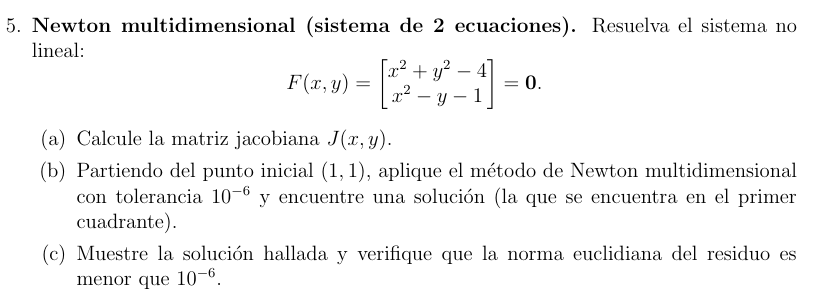

<font face="Times New Roman" size="4"> Empezamos teniendo la matriz con el sistema no lineal:
    
<font face="Times New Roman" size="4">$$F(x,y)=\begin{bmatrix}x^2+y^2-4\\x^2-y-1\end{bmatrix}$$
<br>

<font face="Times New Roman" size="4">**(a)  Calcule la matriz jacobiana $J(x,y)$.**
<br>

<font face="Times New Roman" size="4">La matriz Jacobiana se compone de las derivadas parciales de cada ecuación con respecto a cada variable del sistema ($x$ e $y$):
<font face="Times New Roman" size="4">
* <font face="Times New Roman" size="4">**Para la primera fila $F_1(x,y) = x^2 + y^2 - 4$:**
  * <font face="Times New Roman" size="4"> Derivada parcial respecto a $x$: $\frac{\partial F_1}{\partial x} = 2x$
  * <font face="Times New Roman" size="4"> Derivada parcial respecto a $y$: $\frac{\partial F_1}{\partial y} = 2y$
  
* <font face="Times New Roman" size="4">**Para la segunda fila $F_2(x,y) = x^2 - y - 1$:**
  * <font face="Times New Roman" size="4"> Derivada parcial respecto a $x$: $\frac{\partial F_2}{\partial x} = 2x$
  * <font face="Times New Roman" size="4"> Derivada parcial respecto a $y$: $\frac{\partial F_2}{\partial y} = -1$
  
<font face="Times New Roman" size="4">Construyendo la matriz con estos componentes nos queda:
<font face="Times New Roman" size="4">$$\nabla J(x,y) = \begin{bmatrix} 2x & 2y \\ 2x & -1 \end{bmatrix}$$
<br>

<font face="Times New Roman" size="4">Procedemos a definirlo en código para realizar el método de Newton:
</font>

In [79]:
# Importamos librerías
import numpy as np
#  │     │    │  └─ El alias corto que usaremos en el código.
#  │     │    └─── La palabra clave que asigna el alias.
#  │     └──────── La librería de cálculo numérico que cargamos.
#  └────────────── El comando para traer la librería a memoria.


In [80]:
# Usamos la función de Newton
def NEWTON(f,df,x0,tol,maxiter):
    x=x0
    iter=0
    while (np.linalg.norm(f(x))>tol)&(iter<maxiter):
        iter=iter+1
        x=x-np.dot(np.linalg.inv(df(x)),f(x))
    return x,np.linalg.norm(f(x)),iter

In [81]:
# Definimos las funciones para el sistema
def F5(x):

  # Creamos un vector columna de ceros con dimensiones (2 filas, 1 columna)
    R = np.zeros((2, 1))

    # Recordar la correspondencia de variables en el vector 'x':
    # x[0] representa la variable 'x'
    # x[1] representa la variable 'y'

    # Primera ecuación del sistema: x^2 + y^2 - 4 = 0
    R[0] = x[0] ** 2 + x[1] ** 2 - 4

    # Segunda ecuación del sistema: x^2 - y - 1 = 0
    R[1] = x[0] ** 2 - x[1] - 1
    return R

In [82]:
# @title (a) Calcule la matriz jacobiana $J(x,y)$.
# Definimos para su Jacobiano (Matriz de derivadas parciales)
def dF5(x):
# Creamos la matriz identidad de 2x2 como plantilla
    J = np.eye(2)

    # Rellenamos cada posición con sus respectivas derivadas parciales
    J[0, 0] = 2 * x[0, 0]  # Posición [0,0] -> 2x
    J[0, 1] = 2 * x[1, 0]  # Posición [0,1] -> 2y
    J[1, 0] = 2 * x[0, 0]  # Posición [1,0] -> 2x
    J[1, 1] = -1  # Posición [1,1] -> -1

    return J

In [83]:
# @title (b) Partiendo del punto inicial $(1,1)$, aplique el método de Newton multidimensional con tolerancia $10^{-6}$ y encuentre una solución (la que se encuentra en el primer cuadrante).
# Definimos el array
x0 = np.array([[1.0],
               [1.0]])
x0

array([[1.],
       [1.]])

In [84]:
# @title (c) Muestre la solución hallada y verifique que la norma euclidiana del residuo es menor que $10^{-6}$
# Ejecutamos el método llamando a la función NEWTON
 # Usamos el valor de tolerancia: 10^-6 = 1e-6
 # Usamos 100 como límite de iteraciones
NEWTON(F5, dF5, x0, 1e-6, 100)

(array([[1.51748991],
        [1.30277564]]),
 np.float64(3.16625787273801e-10),
 4)

In [85]:
# @title Tabla de Resultados
# Tabla realizada con ayuda de IA
# Para mostrar resultados obtenidos, guardamos las variables y para tener una mejor vista usamos la librería de pandas
import pandas as pd
import numpy as np

x0 = np.array([[1.0], [1.0]])  # Punto inicial (1,1) como vector columna
tol = 1e-6  # Tolerancia solicitada de 10^-6
maxiter = 100  # Límite de iteraciones
solucion, residuo, iteraciones = NEWTON(F5, dF5, x0, tol, maxiter)

# Almacenamos todas las métricas en un diccionario de datos
datos_resultados = {
    "Concepto / Métrica": [
        "Aproximación final de x",
        "Aproximación final de y",
        "Norma del Residuo obtenido", # <- AQUÍ SE DEMUESTRA LA NORMA
        "¿Residuo menor a 10^-6?",
        "Iteraciones requeridas",
    ],
    "Valor Numérico": [
        f"{solucion.item(0):.8f}",      # Extrae el valor de x
        f"{solucion.item(1):.8f}",      # Extrae el valor de y
        f"{residuo:.16e}",           # Muestra el residuo en notación científica
        str(residuo < tol),          # Evalúa de forma lógica (True/False) si cumplió
        str(iteraciones),
    ],
}

# 1. Convertimos el diccionario a un DataFrame de Pandas
tabla_base = pd.DataFrame(datos_resultados)

# 2. Creamos el MultiIndex para integrar el título en una celda superior fusionada
columnas_con_titulo = pd.MultiIndex.from_product(
    [["(C) TABLA DE VERIFICACIÓN DE RESULTADOS"], tabla_base.columns]
)
tabla_verificacion = pd.DataFrame(tabla_base.values, columns=columnas_con_titulo)

# 3. Aplicamos estilos para los bordes y las cabeceras
tablita = tabla_verificacion.style.set_table_styles([
    # Estilo general para celdas
    {
        'selector': 'th, td',
        'props': [
            ('border', '1.75px solid #FF007F'),  # Rosa Fucsia
            ('padding', '10px'),
            ('text-align', 'center'),
            ('font-family', 'sans-serif')
        ]
    },
    # Celda superior del Título en rosa fuerte con letras blancas
    {
        'selector': 'th.col_heading.level0',
        'props': [
            ('background-color', '#FF007F'),  # Rosa fuerte
            ('color', '#FFFFFF'),             # Texto blanco
            ('font-weight', 'bold')
        ]
    },
    # Subtítulos (Fila 2: "Concepto / Métrica" y "Valor Numérico")
    {
        'selector': 'th.col_heading.level1',
        'props': [
            ('background-color', '#FFBCD6'),
            ('color', '#000000'),
            ('font-weight', 'bold')
        ]
    }
], overwrite=False)

# 4. Aplicamos los fondos en la zona de datos (Fila 3 en adelante)
tablita = tablita.set_properties(
    subset=(slice(None), (("(C) TABLA DE VERIFICACIÓN DE RESULTADOS", "Concepto / Métrica"))),
    **{'background-color': '#FFEDF4'}  # Se queda con rosa clarito para las métricas de abajo
).set_properties(
    subset=(slice(None), (("(C) TABLA DE VERIFICACIÓN DE RESULTADOS", "Valor Numérico"))),
    **{'background-color': '#FFFFFF'}  # Se queda con blanco puro para los números
)

# 5. Quitamos el índice numérico de la izquierda
tablita.hide(axis='index')

# Mostramos la tablita finalizada
tablita


* <font face="Times New Roman" size="5"><b>Conclusión Ejercicio</b></font>
<br>

  *
    * <font face="Times New Roman" size="4">**Verificación de la Norma Euclidiana del Residuo — Enunciado (c)**</font>

<font face="Times New Roman" size="4"> Al finalizar la ejecución del algoritmo en la iteración número 4, la variable residuo (calculada internamente mediante el comando de NumPy np.linalg.norm(f(x)) que está dentro del código de la función de Newton) devolvió un valor de:
<br>

<font face="Times New Roman" size="4">$$\|F(x_k)\| = 3.16625 \times 10^{-10}$$

<font face="Times New Roman" size="4">Como este valor es significativamente menor que la tolerancia exigida de:
<br>

<font face="Times New Roman" size="4">
 $$\text{tol} = 10^{-6}$$

<font face="Times New Roman" size="4"> $$(3.16625 \times 10^{-10} < 10^{-6})$$

<font face="Times New Roman" size="4"> Queda demostrado matemáticamente que el método convergió con éxito y cumple con el criterio de parada del enunciado.
<br>
<br>

  * * <font face="Times New Roman" size="4">**Confirmación de la Ubicación en el Primer Cuadrante — Enunciado (b)**

<font face="Times New Roman" size="4"> El método numérico convergió en el punto coordenado:

<font face="Times New Roman" size="4">$$x \approx 1.51748991$$
<font face="Times New Roman" size="4">$$y \approx 1.30277564$$

<font face="Times New Roman" size="4">Debido a que ambas coordenadas son estrictamente mayores a cero ($x > 0$ e $y > 0$), se confirma que la solución hallada pertenece al Primer Cuadrante del plano cartesiano, validando la restricción geométrica solicitada por el problema. Esto se puede apreciar visualmente en la gráfica generada por el cruce del punto rosa entre la circunferencia y la parábola.</font>

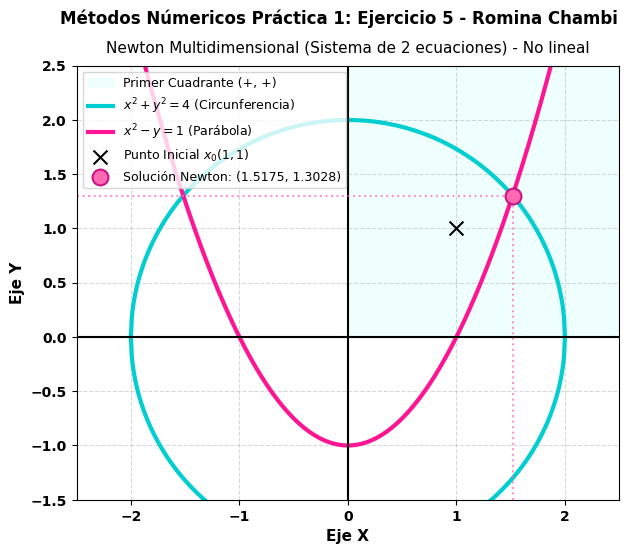

In [86]:
# @title Gráfica del Ejercicio
# Gráfico realizado con ayuda de IA
# Importando librería para graficar
import matplotlib.pyplot as plt

# 1. Rango de 'x' adecuado para poder ver bien ambas funciones
x_circ = np.linspace(-2.0, 2.0, 500)
x_vals = np.linspace(-2.5, 2.5, 500)

# 2. Despejamos 'y' de las ecuaciones
y_circ_superior = np.sqrt(4 - x_circ**2)
y_circ_inferior = -np.sqrt(4 - x_circ**2)
y_parabola = x_vals**2 - 1

# 3. Inicializamos el lienzo
plt.figure(figsize=(7, 6))

# 4. SOMBREAR EL PRIMER CUADRANTE -> TURQUESA CLARO
plt.axvspan(
    0,
    2.5,
    ymin=0.375,
    ymax=1,
    color="#D9FFFE",
    alpha=0.4,
    label="Primer Cuadrante (+, +)",
)

# 5. Dibujamos ambas mitades de la circunferencia
plt.plot(
    x_circ,
    y_circ_superior,
    color="#00CED1",
    linewidth=3,
    label="$x^2 + y^2 = 4$ (Circunferencia)",
)
plt.plot(x_circ, y_circ_inferior, color="#00CED1", linewidth=3)

# Dibujamos la Parábola (Rosa Fuerte)
plt.plot(
    x_vals,
    y_parabola,
    label="$x^2 - y = 1$ (Parábola)",
    color="#FF1493",
    linewidth=3,
)

# 6. RESALTAR LOS EJES CARTESIANOS PRINCIPALES
plt.axhline(0, color="black", linewidth=1.5)
plt.axvline(0, color="black", linewidth=1.5)

# 7. Dibujamos los puntos clave
# Punto Inicial -> NEGRO
plt.scatter(
    1.0,
    1.0,
    color="black",
    s=100,
    marker="x",
    zorder=5,
    label="Punto Inicial $x_0(1,1)$",
)

# Punto Solución -> ROSITA CLARO
plt.scatter(
    solucion[0, 0],
    solucion[1, 0],
    color="#FF69B4",
    s=130,
    edgecolors="#C71585",
    linewidth=1.5,
    zorder=6,
    label=f"Solución Newton: ({solucion[0,0]:.4f}, {solucion[1,0]:.4f})",
)

# 8. Líneas punteadas de proyección hacia los ejes
plt.axhline(
    solucion[1, 0],
    xmin=0,
    xmax=(solucion[0, 0] + 2.5) / 5,
    color="#FF69B4",
    linestyle=":",
    alpha=0.7,
)
plt.axvline(
    solucion[0, 0],
    ymin=0,
    ymax=(solucion[1, 0] + 1.5) / 4,
    color="#FF69B4",
    linestyle=":",
    alpha=0.7,
)

# 9. Configuración de límites y proporción
plt.xlim(-2.5, 2.5)
plt.ylim(-1.5, 2.5)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle="--", alpha=0.3, color="gray")

# PERSONALIZACIÓN DE LOS EJES Y SUS TÍTULOS
plt.xlabel("Eje X", fontsize=11, fontweight="bold", color="black")
plt.ylabel("Eje Y", fontsize=11, fontweight="bold", color="black")

plt.xticks(fontweight="bold", color="black")
plt.yticks(fontweight="bold", color="black")

plt.legend(loc="upper left", fontsize=9)

# TÍTULO Y SUBTÍTULO
# Título principal
plt.suptitle(
    "Métodos Númericos Práctica 1: Ejercicio 5 - Romina Chambi",
    fontsize=12,
    fontweight="bold",
    color="black",
    y=0.95,
)

# Subtítulo
plt.title(
    "Newton Multidimensional (Sistema de 2 ecuaciones) - No lineal",
    fontsize=11,
    color="black",
    pad=10,
)

# Mostrar la gráfica final
plt.show()